# Mental Health in Tech Survey Analysis

An exploratory data analysis of mental health in the tech industry.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Initial Inspection

Loading and initial inspection of the dataset.

In [39]:
Data_df= pd.read_csv('/content/survey.csv')

In [40]:
Data_df.shape

(1259, 27)

Checking dataset shape and first few rows.

In [41]:
Data_df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


Overview of data types, non-null values, and memory usage.

In [42]:
Data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

Identifying missing data to plan imputation or column drops.

In [43]:
Data_df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [44]:
Data_df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


## Data Overview and Initial Cleaning

Inspecting data, checking missing values, and handling 'Age' and 'Gender' inconsistencies. Dropping irrelevant columns.

Droping Useless Columns

In [45]:
Data_df.drop(columns=['Timestamp', 'comments'], inplace=True)

### Cleaning the 'Age' Column

Filtering 'Age' to a reasonable range (18-75).

Cleaning Age

In [46]:
Data_df = Data_df[(Data_df['Age'] >= 18) & (Data_df['Age'] <= 75)]

### Standardizing the 'Gender' Column

Standardizing gender entries to 'Male', 'Female', or 'Other'.

Standardize Gender

In [47]:
Data_df['Gender'] = Data_df['Gender'].str.strip().str.lower()

In [48]:
male = ['male', 'm', 'man', 'cis male', 'male (cis)', 'make', 'maile', 'mal', 'msle', 'mail', 'cis man', 'malr', 'guy (-ish) ^_^']
female = ['female', 'f', 'woman', 'cis female', 'femail', 'cis-female/femme', 'female (cis)', 'femake', 'female ']
other = ['trans-female', 'something kinda male?', 'queer/she/they', 'non-binary', 'nah', 'all', 'enby', 'fluid', 'genderqueer', 'androgyne', 'agender', 'male leaning androgynous', 'trans woman', 'neuter', 'female (trans)', 'queer', 'a little about you', 'p', 'ostensibly male, unsure what that really means']

In [49]:
Data_df['Gender'] = Data_df['Gender'].apply(
    lambda x: 'Male' if x in male else ('Female' if x in female else 'Other')
)

### Handling Missing Values

Imputing missing values in 'self_employed' and 'work_interfere'.

Filling missing values

In [50]:
Data_df['self_employed'].fillna('No', inplace=True)
Data_df['work_interfere'].fillna('Don\'t know', inplace=True)

/tmp/ipykernel_3437/738243266.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Data_df['self_employed'].fillna('No', inplace=True)
/tmp/ipykernel_3437/738243266.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

### Verification After Cleaning

Verifying changes after cleaning: shape, gender distribution, age statistics, and remaining nulls.

### Summary of Data Cleaning Steps

Key cleaning steps: dropping columns, cleaning age, standardizing gender, and handling missing values.

Verifing

In [51]:
Data_df.shape

(1251, 25)

In [52]:
Data_df['Gender'].value_counts()

,count
Gender,
Male,986
Female,247
Other,18


Descriptive statistics for 'Age' after cleaning.

In [53]:
Data_df['Age'].describe()

,Age
count,1251.000000
mean,32.076739
std,7.288272
min,18.000000
25%,27.000000
50%,31.000000
75%,36.000000
max,72.000000


Confirming no missing values in key columns post-cleaning.

In [54]:
Data_df.isnull().sum()

,0
Age,0
Gender,0
Country,0
state,513
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0
remote_work,0


## Visualizing Key Relationships

Visualizing relationships between factors and mental health treatment.

In [55]:
sns.set_style('whitegrid')

### Chart 1: Treatment by Gender

Visualizing mental health treatment sought by gender.

Chart 1 — Treatment by Gender

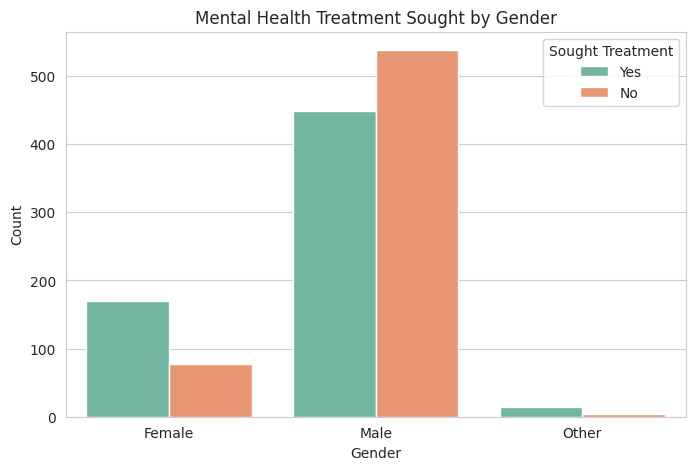

In [56]:
plt.figure(figsize=(8,5))
sns.countplot(data=Data_df, x='Gender', hue='treatment', palette='Set2')
plt.title('Mental Health Treatment Sought by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Sought Treatment');

### Chart 2: Work Interference

Frequency of mental health interfering with work.

Chart 2 — Work Interference with Mental Health

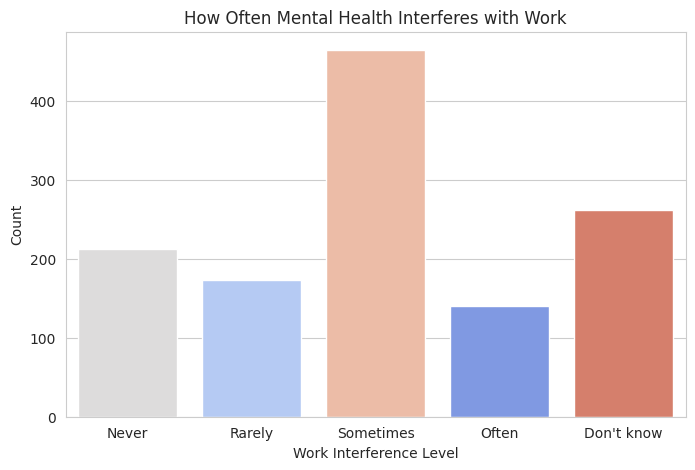

In [57]:
plt.figure(figsize=(8,5))
order = ['Never', 'Rarely', 'Sometimes', 'Often', "Don't know"]
sns.countplot(data=Data_df, x='work_interfere', order=order, palette='coolwarm', hue='work_interfere', legend=False)
plt.title('How Often Mental Health Interferes with Work')
plt.xlabel('Work Interference Level')
plt.ylabel('Count');

### Chart 3: Treatment by Company Size

Treatment rates across different company sizes.

Chart 3 — Treatment by Company Size

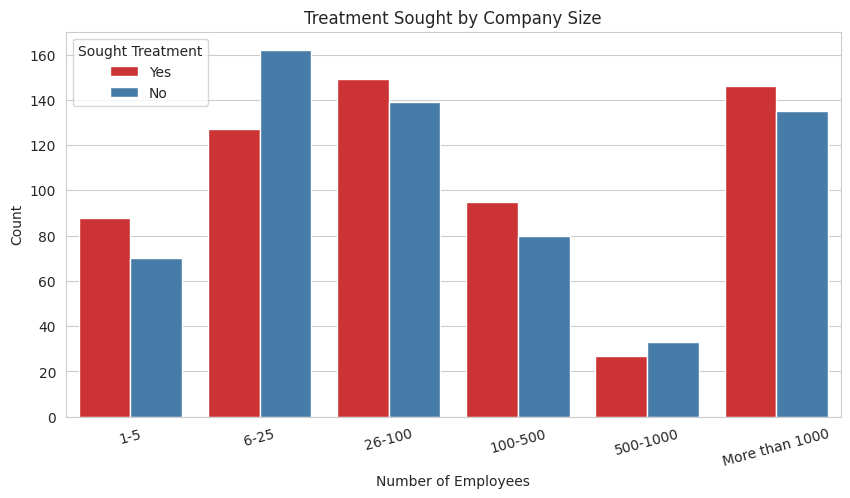

In [58]:
plt.figure(figsize=(10,5))
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
sns.countplot(data=Data_df, x='no_employees', hue='treatment', order=order, palette='Set1')
plt.title('Treatment Sought by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Sought Treatment');

### Chart 4: Remote Work vs Treatment

Comparing treatment rates for remote vs. non-remote workers.

Chart 4 — Remote Work vs Treatment

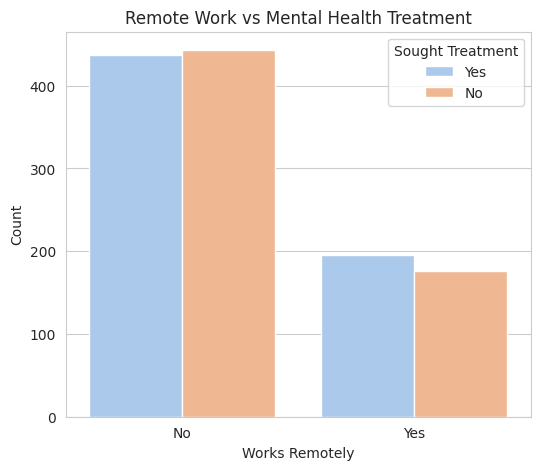

In [59]:
plt.figure(figsize=(6,5))
sns.countplot(data=Data_df, x='remote_work', hue='treatment', palette='pastel')
plt.title('Remote Work vs Mental Health Treatment')
plt.xlabel('Works Remotely')
plt.ylabel('Count')
plt.legend(title='Sought Treatment');

### Chart 5: Family History vs Treatment

Influence of family history on seeking mental health treatment.

Chart 5 — Family History vs Treatment

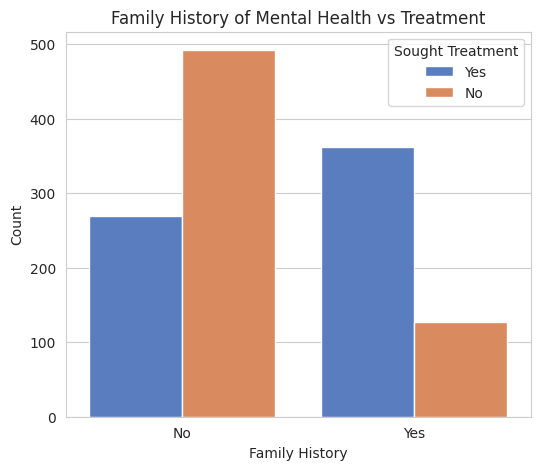

In [60]:
plt.figure(figsize=(6,5))
sns.countplot(data=Data_df, x='family_history', hue='treatment', palette='muted')
plt.title('Family History of Mental Health vs Treatment')
plt.xlabel('Family History')
plt.ylabel('Count')
plt.legend(title='Sought Treatment');

## Age Distribution and Statistics

Analyzing age distribution and statistics, broken down by gender.

Age Distribution

In [61]:
print(f"Mean Age   : {np.mean(Data_df['Age']):.2f}")
print(f"Median Age : {np.median(Data_df['Age']):.2f}")
print(f"Std Dev    : {np.std(Data_df['Age']):.2f}")
print(f"Min Age    : {np.min(Data_df['Age'])}")
print(f"Max Age    : {np.max(Data_df['Age'])}")

Mean Age   : 32.08
Median Age : 31.00
Std Dev    : 7.29
Min Age    : 18
Max Age    : 72


Numerical summary of age distribution.

Age stats grouped by Gender

Age statistics broken down by gender.

In [62]:
for gender in Data_df['Gender'].unique():
    ages = Data_df[Data_df['Gender'] == gender]['Age'].values
    print(f"\n{gender}:")
    print(f"  Mean   : {np.mean(ages):.2f}")
    print(f"  Median : {np.median(ages):.2f}")
    print(f"  Std    : {np.std(ages):.2f}")


Female:
  Mean   : 30.93
  Median : 30.00
  Std    : 6.73

Male:
  Mean   : 32.43
  Median : 32.00
  Std    : 7.38

Other:
  Mean   : 28.28
  Median : 28.00
  Std    : 6.67


Raw counts and percentages for 'treatment' and 'work_interfere'.

Treatment breakdown with percentage

In [63]:
print("Treatment Breakdown:")
counts = Data_df['treatment'].value_counts()
percentages = Data_df['treatment'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
print(summary)

print("\nWork Interference Breakdown:")
counts2 = Data_df['work_interfere'].value_counts()
pct2 = Data_df['work_interfere'].value_counts(normalize=True) * 100
summary2 = pd.DataFrame({'Count': counts2, 'Percentage (%)': pct2.round(2)})
print(summary2)

Treatment Breakdown:
           Count  Percentage (%)
treatment                       
Yes          632           50.52
No           619           49.48

Work Interference Breakdown:
                Count  Percentage (%)
work_interfere                       
Sometimes         464           37.09
Don't know        262           20.94
Never             212           16.95
Rarely            173           13.83
Often             140           11.19


## Crosstabulations and Proportional Analysis

Analyzing relationships between categorical variables and treatment using crosstabulations.

Crosstab — Gender vs Treatment

In [64]:
print("Crosstab: Gender vs Treatment")
ct1 = pd.crosstab(Data_df['Gender'], Data_df['treatment'], margins=True)
print(ct1)

print("\nCrosstab: Family History vs Treatment")
ct2 = pd.crosstab(Data_df['family_history'], Data_df['treatment'],
                   margins=True, normalize='index').round(3) * 100
print(ct2)

print("\nCrosstab: Remote Work vs Treatment")
ct3 = pd.crosstab(Data_df['remote_work'], Data_df['treatment'],
                   margins=True, normalize='index').round(3) * 100
print(ct3)

Crosstab: Gender vs Treatment
treatment   No  Yes   All
Gender                   
Female      77  170   247
Male       538  448   986
Other        4   14    18
All        619  632  1251

Crosstab: Family History vs Treatment
treatment         No   Yes
family_history            
No              64.6  35.4
Yes             26.0  74.0
All             49.5  50.5

Crosstab: Remote Work vs Treatment
treatment      No   Yes
remote_work            
No           50.3  49.7
Yes          47.4  52.6
All          49.5  50.5


### Encoding Categorical Columns

Encoding categorical columns for correlation analysis.

Encode categorical columns for correlation

In [65]:
encode_cols = ['treatment', 'Gender', 'self_employed', 'family_history',
               'remote_work', 'tech_company', 'benefits', 'seek_help',
               'anonymity', 'mental_health_consequence', 'obs_consequence']

## Correlation Heatmap of Mental Health Factors

Visualizing correlations between encoded categorical factors and 'Age' using a heatmap.

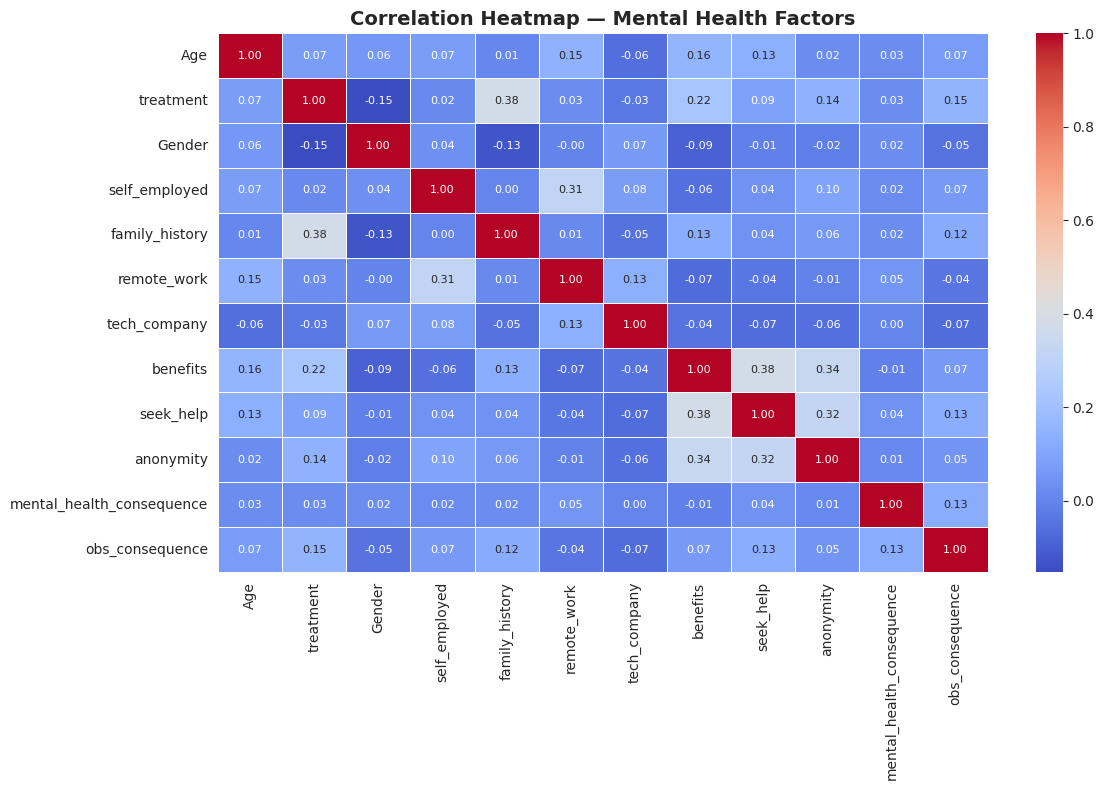

In [66]:
df_encoded = Data_df.copy()
for col in encode_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

corr = df_encoded[['Age'] + encode_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Mental Health Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Age Distribution Histogram

Visualizing age distribution with mean and median.

Age Distribution Histogram

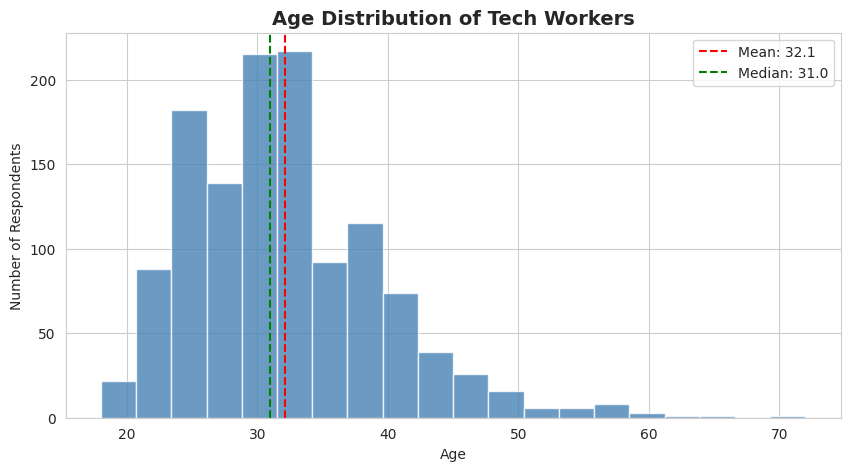

In [67]:
plt.figure(figsize=(10, 5))
plt.hist(Data_df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(np.mean(Data_df['Age']), color='red', linestyle='--', label=f"Mean: {np.mean(Data_df['Age']):.1f}")
plt.axvline(np.median(Data_df['Age']), color='green', linestyle='--', label=f"Median: {np.median(Data_df['Age']):.1f}")
plt.title('Age Distribution of Tech Workers', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Respondents')
plt.legend();

### Top 10 Countries

Bar chart showing top 10 countries by respondent count.

Top 10 Countries Chart

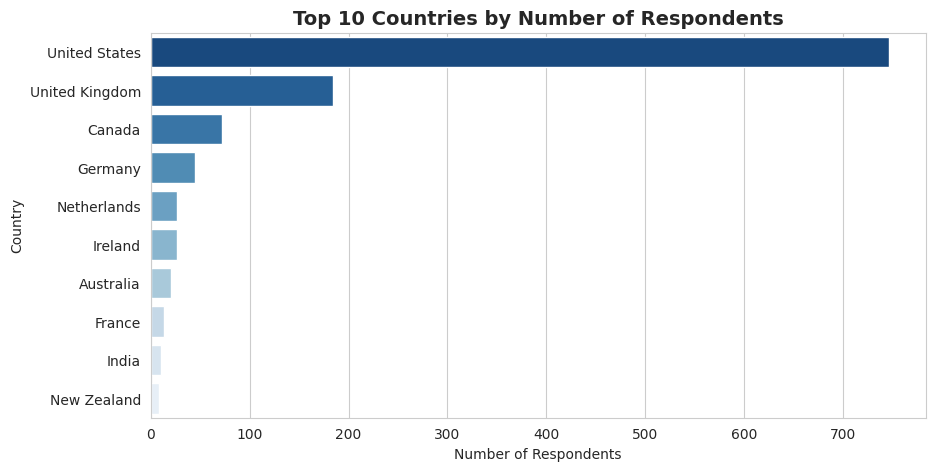

In [68]:
top_countries = Data_df['Country'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r', hue=top_countries.index, legend=False)
plt.title('Top 10 Countries by Number of Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Number of Respondents')
plt.ylabel('Country');

### Treatment Rate by Top 10 Countries

Percentage of respondents seeking treatment by country.

Treatment Rate by Top 10 Countries

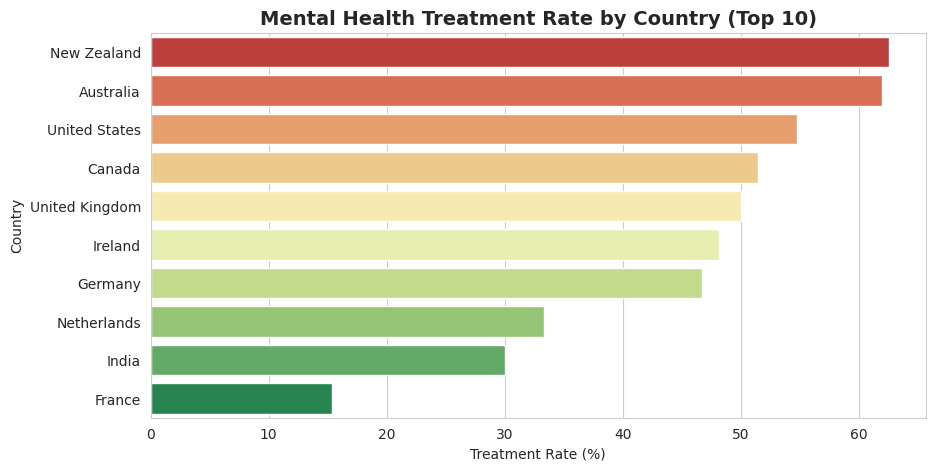

In [69]:
top10 = Data_df['Country'].value_counts().head(10).index
df_top10 = Data_df[Data_df['Country'].isin(top10)]
country_treatment = df_top10.groupby('Country')['treatment'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=country_treatment.values, y=country_treatment.index, palette='RdYlGn', hue=country_treatment.index, legend=False)
plt.title('Mental Health Treatment Rate by Country (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Treatment Rate (%)')
plt.ylabel('Country');

### Benefits vs Treatment

Stacked bar chart showing workplace benefits and treatment sought.

Stacked Bar Chart (Benefits vs Treatment)

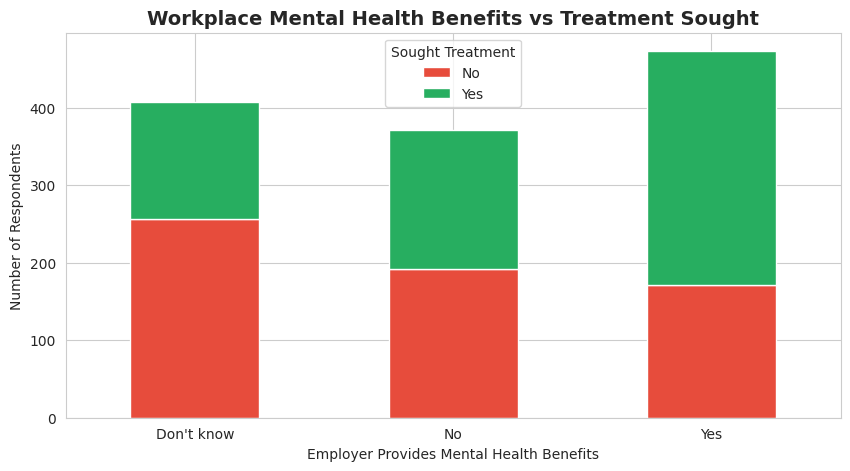

In [70]:
ct = pd.crosstab(Data_df['benefits'], Data_df['treatment'])
ct.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#E74C3C', '#27AE60'], edgecolor='white')
plt.title('Workplace Mental Health Benefits vs Treatment Sought', fontsize=14, fontweight='bold')
plt.xlabel('Employer Provides Mental Health Benefits')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Sought Treatment');

## Respondent Profile: Self-Employed and Tech Company

Pie charts summarizing self-employment and tech company representation.

Pie Charts (Self Employed & Tech Company)

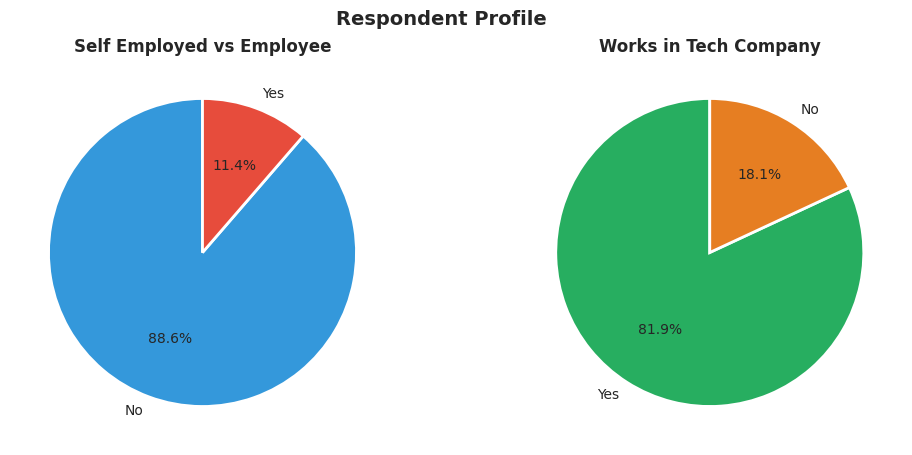

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie 1 - Self Employed
se = Data_df['self_employed'].value_counts()
axes[0].pie(se.values, labels=se.index, autopct='%1.1f%%',
            colors=['#3498DB', '#E74C3C'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Self Employed vs Employee', fontweight='bold')

# Pie 2 - Tech Company
tc = Data_df['tech_company'].value_counts()
axes[1].pie(tc.values, labels=tc.index, autopct='%1.1f%%',
            colors=['#27AE60', '#E67E22'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Works in Tech Company', fontweight='bold')

plt.suptitle('Respondent Profile', fontsize=14, fontweight='bold');

### Exporting Cleaned Data

Exporting the cleaned dataset to Excel.

Export cleaned data to Excel

In [72]:
Data_df.to_excel('mental_health_cleaned.xlsx', index=False)
print("✅ File saved! Download it from Colab's file panel.")

✅ File saved! Download it from Colab's file panel.


## Wrapping Up: What We Learned

So, what did we find out about mental health in the tech world? We've seen how things like gender, company size, whether you work remotely, and even family history can play a role in whether someone seeks help. This exploration has given us a good starting point to understand the big picture. We've even got our cleaned data saved, ready for anyone who wants to dig deeper or perhaps even try to predict future trends. This was just the beginning!